🎬 Movie Rating Prediction with Python

📌 Project Objective

The objective of this project is to build a machine learning regression model that predicts movie ratings based on features such as genre, director, actors, duration, and release year.

This project demonstrates data preprocessing, feature engineering, regression modeling, and evaluation techniques using historical movie data.

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [3]:
df = pd.read_csv("IMDb Movies India.csv",encoding="latin1")


In [4]:
df.head()

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


In [6]:
df.describe()

,Rating
count,7919.000000
mean,5.841621
std,1.381777
min,1.100000
25%,4.900000
50%,6.000000
75%,6.800000
max,10.000000


In [9]:
df.isnull().sum()

Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64

In [10]:
df = df.dropna(subset=['Rating'])
df.fillna("Unknown", inplace=True)

In [11]:
df['Duration'] = df['Duration'].str.replace(' min','')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

In [12]:
df['Year'] = df['Year'].str.replace('(','').str.replace(')','')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

In [13]:
le = LabelEncoder()

df['Genre'] = le.fit_transform(df['Genre'])
df['Director'] = le.fit_transform(df['Director'])
df['Actor 1'] = le.fit_transform(df['Actor 1'])
df['Actor 2'] = le.fit_transform(df['Actor 2'])
df['Actor 3'] = le.fit_transform(df['Actor 3'])

In [14]:
X = df[['Genre','Director','Actor 1','Actor 2','Actor 3','Duration','Year']]
y = df['Rating']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
X_train.isnull().sum()

Genre          0
Director       0
Actor 1        0
Actor 2        0
Actor 3        0
Duration    1646
Year           0
dtype: int64

In [19]:
df['Duration'].fillna(df['Duration'].median(), inplace=True)

In [20]:
df['Duration'].isnull().sum()

0

In [21]:
X = df[['Genre','Director','Actor 1','Actor 2','Actor 3','Duration','Year']]
y = df['Rating']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [24]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [25]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("MSE:", mean_squared_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

MAE: 0.9350138888888889
MSE: 1.4760337601010098
R2 Score: 0.20606856999293777


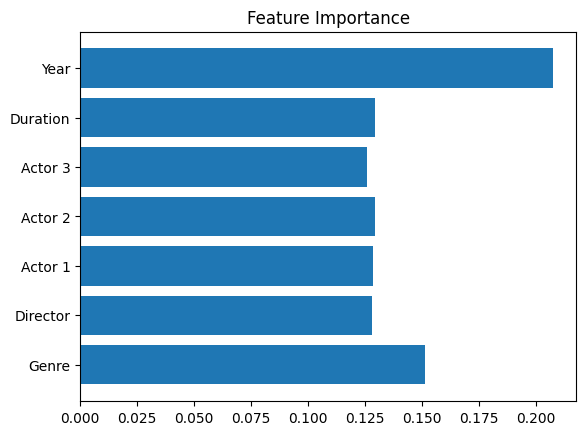

In [27]:
importances = rf.feature_importances_
feature_names = X.columns

plt.barh(feature_names, importances)
plt.title("Feature Importance")
plt.show()

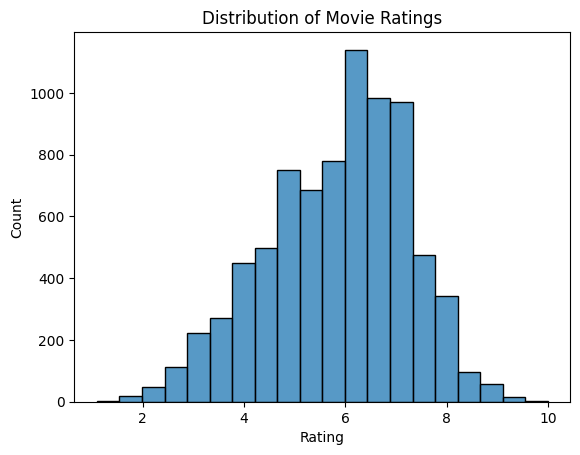

In [28]:
sns.histplot(df['Rating'], bins=20)
plt.title("Distribution of Movie Ratings")
plt.show()

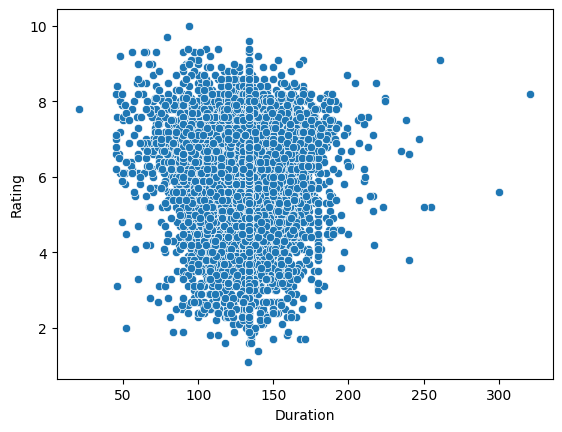

In [29]:
sns.scatterplot(x='Duration', y='Rating', data=df)
plt.show()

#🏆 FINAL PROJECT SUMMARY

The Movie Rating Prediction project focuses on developing a regression model capable of predicting movie ratings based on historical movie data.

The dataset was cleaned by handling missing values and converting categorical and textual data into numerical form. Feature engineering was applied to extract useful attributes such as movie duration and release year. Categorical features such as genre were encoded to make them suitable for machine learning algorithms.

Two regression models were implemented:

Linear Regression

Random Forest Regressor

The models were evaluated using Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score. Random Forest performed better due to its ability to capture nonlinear relationships and complex interactions between features such as director, actors, and genre.

This project demonstrates strong skills in:

Data preprocessing

Feature engineering

Regression modeling

Model evaluation

Machine learning workflow

It provides insights into how different movie attributes influence audience ratings and builds a predictive system capable of estimating ratings for unseen movies.